In [ ]:
#!/usr/bin/env python3
"""
Compute descriptive statistics and pairwise Mann–Whitney U tests
for four independent “single”-session groups, using each ROI’s
95th-percentile dF/F as the measurement.
"""

import os
import json
import glob
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# ----------------------------------------------------------------------------
# Load exclusion mapping and HDF5-loading / ROI-matrix builders (unchanged)
# ----------------------------------------------------------------------------
exclude_json_path = '/home/lq53/mir_repos/BBOP/random_tests/25feb_more_corr_explo/neuro_exclude.json'
with open(exclude_json_path, 'r') as f:
    exclude_mapping = json.load(f)

def get_excluded_neurons_for_session(session_path, exclude_dict):
    if not isinstance(exclude_dict, dict):
        return []
    if session_path in exclude_dict:
        return exclude_dict[session_path]
    for key, val in exclude_dict.items():
        if key in session_path:
            return val
    return []

def load_session_data(rec_path):
    h5_dir = os.path.join(rec_path, 'MIR_Aligned')
    pattern = '*aligned_predictions_with_ca_and_dF_F*.h5'
    h5_files = glob.glob(os.path.join(h5_dir, pattern))
    if not h5_files:
        raise FileNotFoundError(f"No .h5 found in {h5_dir}")
    df = pd.read_hdf(h5_files[0], key='df')
    if df.index.name == 'timestamp_ms_mini':
        df = df.reset_index()
    df['session_path'] = rec_path
    return df

def build_neuron_matrix_raw(df, exclude_dict):
    if df.index.name == 'timestamp_ms_mini':
        df = df.reset_index()
    sess = df['session_path'].iloc[0]
    excluded = get_excluded_neurons_for_session(sess, exclude_dict)
    all_names = [c for c in df.columns if c.startswith('dF_F_roi')]
    keep_names = []
    for c in all_names:
        try:
            idx = int(c.split('_')[-1][3:])
        except:
            continue
        if idx not in excluded:
            keep_names.append(c)
    if not keep_names:
        return [], np.zeros((0, len(df)))
    activity = df[keep_names].values.T
    variances = np.var(activity, axis=1)
    cutoff = np.percentile(variances, 5) if variances.size else 0
    keep_mask = variances > cutoff
    kept_names = [keep_names[i] for i in range(len(keep_names)) if keep_mask[i]]
    filtered = activity[keep_mask, :]
    return kept_names, filtered

def get_single_stats(rec_path, exclude_dict, pct=95):
    df = load_session_data(rec_path)
    roi_names, mat_raw = build_neuron_matrix_raw(df, exclude_dict)
    if mat_raw.size == 0:
        return [], np.array([])
    stat_all = np.nanpercentile(mat_raw, pct, axis=1)
    return roi_names, stat_all

def aggregate_single_stats(sessions, exclude_dict, pct=95):
    all_vals = []
    for rec_path in sessions:
        try:
            _, stat = get_single_stats(rec_path, exclude_dict, pct)
        except Exception as e:
            print(f"  Skipping {rec_path}: {e}")
            continue
        valid = ~np.isnan(stat)
        all_vals.extend(stat[valid].tolist())
    return np.array(all_vals)

# ----------------------------------------------------------------------------
# Pairwise comparison & reporting
# ----------------------------------------------------------------------------
def desc_stats(arr):
    return {
        'n':      int(np.count_nonzero(~np.isnan(arr))),
        'mean':   float(np.nanmean(arr)),
        'std':    float(np.nanstd(arr)),
        'median': float(np.nanmedian(arr))
    }

def print_group_stats(name, arr):
    s = desc_stats(arr)
    print(f"{name:12} n={s['n']:4}, mean={s['mean']:.3f}, std={s['std']:.3f}, median={s['median']:.3f}")

def compare_groups(name1, arr1, name2, arr2):
    if arr1.size and arr2.size:
        u, p = mannwhitneyu(arr1, arr2, alternative='two-sided')
        print(f"{name1} vs {name2:12} U={u:.1f}, p={p:.4f}")
    else:
        print(f"{name1} vs {name2:12} insufficient data")

# ----------------------------------------------------------------------------
# Main: define your four session-path lists here
# ----------------------------------------------------------------------------
if __name__ == '__main__':
    pct = 95

    group1_sessions = [
        "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup"
    ]
    group2_sessions = [
        "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup"
    ]
    group3_sessions = [
        "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup"
    ]
    group4_sessions = [
        "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearecup"
    ]

    groups = {
        'green empty cup': aggregate_single_stats(group1_sessions, exclude_mapping, pct),
        'green social cup': aggregate_single_stats(group2_sessions, exclude_mapping, pct),
        'clear social cup': aggregate_single_stats(group3_sessions, exclude_mapping, pct),
        'clear empty cup': aggregate_single_stats(group4_sessions, exclude_mapping, pct),
    }

    print("\n=== Descriptive Statistics ===")
    for name, arr in groups.items():
        print_group_stats(name, arr)

    print("\n=== Pairwise Mann–Whitney U Tests ===")
    names = list(groups.keys())
    for i in range(len(names)):
        for j in range(i+1, len(names)):
            compare_groups(names[i], groups[names[i]], names[j], groups[names[j]])



=== Descriptive Statistics ===
green empty cup n= 100, mean=5.477, std=3.795, median=4.135
green social cup n= 105, mean=5.272, std=2.999, median=4.488
clear social cup n= 103, mean=5.802, std=2.799, median=4.909
clear empty cup n= 105, mean=7.558, std=25.271, median=4.295

=== Pairwise Mann–Whitney U Tests ===
green empty cup vs green social cup U=4991.0, p=0.5426
green empty cup vs clear social cup U=4096.0, p=0.0118
green empty cup vs clear empty cup U=5501.0, p=0.5552
green social cup vs clear social cup U=4549.0, p=0.0480
green social cup vs clear empty cup U=5972.0, p=0.2972
clear social cup vs clear empty cup U=6572.0, p=0.0073


In [ ]:
# just fitting, but not cencered. so this method is a bit too deviated...

# import os, glob
# import pandas as pd
# import numpy as np
# from sklearn.cluster import DBSCAN
# import matplotlib.pyplot as plt

# def load_com_h5(rec_path):
#     """
#     Load aligned_predictions_with_ca_and_dF_F*.h5 → df,
#     extract COM_x & COM_y as an (N,2) array.
#     """
#     h5_dir = os.path.join(rec_path, 'MIR_Aligned')
#     pattern = '*aligned_predictions_with_ca_and_dF_F*.h5'
#     files = glob.glob(os.path.join(h5_dir, pattern))
#     if not files:
#         raise FileNotFoundError(f"No .h5 in {h5_dir}")
#     df = pd.read_hdf(files[0], key='df')
    
#     # <-- EDIT these if your columns differ -->
#     xcol, ycol = 'com1_x', 'com1_y'
#     # -----------------------------------------
    
#     if xcol not in df.columns or ycol not in df.columns:
#         raise KeyError(f"Couldn't find {xcol}/{ycol} in:\n  {list(df.columns)}")
#     return df[[xcol, ycol]].values

# def detect_interaction_region(pts, eps=15, min_samples=100, pct=95):
#     """
#     DBSCAN on pts (N×2) → largest cluster centroid + 95th‐pct radius.
#     """
#     db = DBSCAN(eps=eps, min_samples=min_samples).fit(pts)
#     labels = db.labels_
#     mask   = labels >= 0
#     if not mask.any():
#         return None, None
#     lab, cnt = np.unique(labels[mask], return_counts=True)
#     main     = lab[np.argmax(cnt)]
#     reg_pts  = pts[labels == main]
#     ctr      = reg_pts.mean(axis=0)
#     dists    = np.linalg.norm(reg_pts - ctr, axis=1)
#     radius   = np.percentile(dists, pct)
#     return ctr, radius

# def plot_com_interaction(rec_path, eps=15, min_samples=100, vis_dir='vis'):
#     pts = load_com_h5(rec_path)
#     center, r = detect_interaction_region(pts, eps, min_samples)

#     fig, ax = plt.subplots(figsize=(6,6))
#     if center is not None:
#         d      = np.linalg.norm(pts - center, axis=1)
#         inside = d <= r
#         ax.scatter(pts[~inside,0], pts[~inside,1], s=2, alpha=0.3, label='out')
#         ax.scatter(pts[ inside,0], pts[ inside,1], s=4, alpha=0.6, label='in')
#         θ = np.linspace(0,2*np.pi,200)
#         ax.plot(center[0]+r*np.cos(θ), center[1]+r*np.sin(θ),
#                 'r--', lw=2, label='region')
#     else:
#         ax.scatter(pts[:,0], pts[:,1], s=3, alpha=0.4, label='COM')

#     ax.set_aspect('equal')
#     ax.set_title(os.path.basename(rec_path))
#     ax.legend()

#     out = os.path.join(rec_path, vis_dir)
#     os.makedirs(out, exist_ok=True)
#     fn  = os.path.join(out, 'com_interaction.png')
#     fig.tight_layout()
#     fig.savefig(fn, dpi=300)
#     # fig.show()
#     plt.close(fig)
#     print(f"→ {fn}")

# # ————— EDIT THIS LIST —————
# sessions = [
#     "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup",

#     # etc.
# ]
# # ————————————————

# eps         = 15   # spatial scale, in same units as COM coords
# min_samples = 10   # how many frames to form a cluster

# for sess in sessions:
#     try:
#         plot_com_interaction(sess, eps=eps, min_samples=min_samples, vis_dir='vis')
#     except Exception as e:
#         print(f"Error on {sess}: {e}")

Error on /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup: detect_interaction_region() missing 1 required positional argument: 'pts'


In [46]:
# In[ ]:

import os, glob
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from scipy.spatial import ConvexHull
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

def load_com_h5(rec_path):
    """Load aligned_predictions_with_ca_and_dF_F*.h5 → df, extract COM_x & COM_y."""
    h5_dir = os.path.join(rec_path, 'MIR_Aligned')
    files  = glob.glob(os.path.join(h5_dir, '*aligned_predictions_with_ca_and_dF_F*.h5'))
    if not files:
        raise FileNotFoundError(f"No .h5 in {h5_dir}")
    df = pd.read_hdf(files[0], key='df')
    xcol, ycol = 'com1_x', 'com1_y'
    if xcol not in df or ycol not in df:
        raise KeyError(f"Missing {xcol}/{ycol} in columns: {df.columns.tolist()}")
    return df[[xcol, ycol]].values

def fit_circle_hull(pts):
    """Fit (xc,yc,r) to convex‐hull of pts via least squares."""
    hull = ConvexHull(pts)
    pts_h = pts[hull.vertices]
    # initial guess: centroid & mean distance
    cx0, cy0 = pts_h.mean(axis=0)
    r0 = np.mean(np.hypot(pts_h[:,0]-cx0, pts_h[:,1]-cy0))
    def resid(params):
        dx = pts_h[:,0] - params[0]
        dy = pts_h[:,1] - params[1]
        return np.hypot(dx,dy) - params[2]
    sol = least_squares(resid, x0=(cx0,cy0,r0))
    return sol.x  # xc, yc, r

def detect_interaction_region(pts, eps=15, min_samples=100):
    """
    DBSCAN → largest cluster → hull‐circle fit.
    Returns (xc, yc, r) or (None, None, None) if no cluster.
    """
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(pts)
    labels = db.labels_
    mask   = labels >= 0
    if not mask.any():
        return None, None, None
    labs, cnts = np.unique(labels[mask], return_counts=True)
    main = labs[np.argmax(cnts)]
    cluster_pts = pts[labels==main]
    return fit_circle_hull(cluster_pts)

def plot_com_interaction(rec_path, eps=15, min_samples=100, vis_dir='vis'):
    pts = load_com_h5(rec_path)
    xc, yc, r = detect_interaction_region(pts, eps, min_samples)

    fig, ax = plt.subplots(figsize=(6,6))
    if xc is not None:
        d      = np.hypot(pts[:,0]-xc, pts[:,1]-yc)
        inside = d <= r
        ax.scatter(pts[~inside,0], pts[~inside,1], s=2, alpha=0.3, label='out')
        ax.scatter(pts[ inside,0], pts[ inside,1], s=4, alpha=0.6, label='in')
        θ = np.linspace(0,2*np.pi,200)
        ax.plot(xc + r*np.cos(θ), yc + r*np.sin(θ),
                'r--', lw=2, label='fit circle')
    else:
        ax.scatter(pts[:,0], pts[:,1], s=3, alpha=0.4, label='COM')

    ax.set_aspect('equal')
    ax.set_title(os.path.basename(rec_path))
    ax.legend()

    out = os.path.join(rec_path, vis_dir)
    os.makedirs(out, exist_ok=True)
    fn = os.path.join(out, 'com_interaction_circle.png')
    fig.tight_layout()
    fig.savefig(fn, dpi=300)
    plt.close(fig)
    print(f"→ {fn}")

# ——— configure and run ———
sessions = [
    # "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup", #10,50
    # "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup" #13,50
    # "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup" #12,50
# "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearecup" #12,50
"/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup"
]
eps, min_samples = 10, 50

for sess in sessions:
    try:
        plot_com_interaction(sess, eps=eps, min_samples=min_samples)
    except Exception as e:
        print(f"Error on {sess}: {e}")


→ /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup/vis/com_interaction_circle.png


In [39]:
# maybe if we do not need to have the customized parameters...

#!/usr/bin/env python3
import os, glob, json
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull
from scipy.optimize import least_squares
from sklearn.cluster import DBSCAN
from scipy.stats import mannwhitneyu

# ——— 1. Load COM *with* timestamps ———
def load_com_df(rec_path):
    """Return a DataFrame with columns ['timestamp_ms_mini','com1_x','com1_y']."""
    h5_dir = os.path.join(rec_path, 'MIR_Aligned')
    files = glob.glob(os.path.join(h5_dir, '*aligned_predictions_with_ca_and_dF_F*.h5'))
    if not files:
        raise FileNotFoundError(f"No .h5 in {h5_dir}")
    df = pd.read_hdf(files[0], key='df')
    # restore timestamp if it was the index
    if df.index.name == 'timestamp_ms_mini':
        df = df.reset_index()
    return df[['timestamp_ms_mini', 'com1_x', 'com1_y']]

# ——— 2. Fit circle to the largest DBSCAN cluster ———
def fit_circle_hull(pts):
    hull = ConvexHull(pts)
    ph = pts[hull.vertices]
    cx0, cy0 = ph.mean(axis=0)
    r0 = np.mean(np.hypot(ph[:,0]-cx0, ph[:,1]-cy0))
    def resid(p):
        return np.hypot(ph[:,0]-p[0], ph[:,1]-p[1]) - p[2]
    sol = least_squares(resid, x0=(cx0, cy0, r0))
    return sol.x  # xc, yc, r

def detect_region(pts, eps=12, min_samples=50):
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(pts)
    labels = db.labels_
    mask = labels >= 0
    if not mask.any():
        return None, None, None
    labs, counts = np.unique(labels[mask], return_counts=True)
    main = labs[np.argmax(counts)]
    return fit_circle_hull(pts[labels==main])

# ——— 3. Segment each frame as inside/outside + save ———
def segment_and_save(rec_path, eps=12, min_samples=50):
    com = load_com_df(rec_path)
    pts = com[['com1_x','com1_y']].values
    xc, yc, r = detect_region(pts, eps, min_samples)

    if xc is None:
        raise RuntimeError("No interaction region found")

    # label frames
    d2 = (com['com1_x']-xc)**2 + (com['com1_y']-yc)**2
    com['inside'] = d2 <= r**2

    # save CSV and JSON
    out = os.path.join(rec_path, 'vis')
    os.makedirs(out, exist_ok=True)
    com.to_csv(os.path.join(out, 'com_interaction_segments.csv'), index=False)
    with open(os.path.join(out, 'com_interaction_params.json'), 'w') as f:
        json.dump({'xc': xc, 'yc': yc, 'r': r}, f)

    return com

# ——— 4. Merge with neural data and compare stats ———
def load_neural_df(rec_path, exclude_dict):
    # your existing load_session_data + build_neuron_matrix_raw pipeline
    # here assume it returns (roi_names, data_matrix, timestamps)
    df = pd.read_hdf(glob.glob(os.path.join(rec_path,'MIR_Aligned','*aligned_predictions_with_ca_and_dF_F*.h5'))[0], 'df')
    if df.index.name=='timestamp_ms_mini': df=df.reset_index()
    df['session_path'] = rec_path
    # pick out only dF/F columns
    roi_cols = [c for c in df.columns if c.startswith('dF_F_roi')]
    return df[['timestamp_ms_mini']+roi_cols]

def compare_in_out(rec_path, exclude_dict, pct=95, eps=12, min_samples=50):
    # segment COM
    com_seg = segment_and_save(rec_path, eps, min_samples)
    # load neural data
    nd = load_neural_df(rec_path, exclude_dict)
    # merge on timestamp
    merged = pd.merge(nd, com_seg[['timestamp_ms_mini','inside']],
                      on='timestamp_ms_mini', how='inner')

    # build activity matrix: ROIs × timepoints
    roi_cols = [c for c in merged.columns if c.startswith('dF_F_roi')]
    mat = merged[roi_cols].values.T  # shape (n_rois, n_frames)
    inside = merged['inside'].values

    # 95th‐percentile per ROI
    stat_in  = np.nanpercentile(mat[:, inside],  pct, axis=1) if inside.any()  else np.array([])
    stat_out = np.nanpercentile(mat[:, ~inside], pct, axis=1) if (~inside).any() else np.array([])

    # descriptive
    def desc(a):
        return dict(n=int(~np.isnan(a).sum()),
                    mean=float(np.nanmean(a)),
                    median=float(np.nanmedian(a)),
                    std=float(np.nanstd(a)))
    stats = {'inside': desc(stat_in), 'outside': desc(stat_out)}

    # Mann–Whitney U
    if stat_in.size and stat_out.size:
        u, p = mannwhitneyu(stat_in, stat_out, alternative='two-sided')
        stats['MWU'] = {'U': float(u), 'p': float(p)}
    else:
        stats['MWU'] = None

    # write a JSON summary
    out = os.path.join(rec_path, 'vis')
    with open(os.path.join(out, 'in_out_stats.json'), 'w') as f:
        json.dump(stats, f, indent=2)

    return stats

# # ——— Example usage ———
# if __name__=='__main__':
#     exclude_json = '/home/lq53/mir_repos/BBOP/random_tests/25feb_more_corr_explo/neuro_exclude.json'
#     with open(exclude_json) as f:
#         exclude_mapping = json.load(f)

#     sessions = [
#       "/data/.../20250512PMCl23r1_greenecup",
#       # etc.
#     ]
#     for sess in sessions:
#         try:
#             result = compare_in_out(sess, exclude_mapping,
#                                     pct=95, eps=12, min_samples=50)
#             print(sess, result)
#         except Exception as e:
#             print(f"Failed on {sess}: {e}")


if __name__ == '__main__':
    # Full path to your exclusion JSON
    exclude_json = '/home/lq53/mir_repos/BBOP/random_tests/25feb_more_corr_explo/neuro_exclude.json'
    with open(exclude_json) as f:
        exclude_mapping = json.load(f)

    # List of (session_path, eps, min_samples)
    sessions = [
        ("/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup", 10, 50),
        ("/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup", 13, 50),
        ("/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup", 12, 50),
        ("/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearecup", 12, 50),
    ]

    for sess, eps, min_samples in sessions:
        try:
            stats = compare_in_out(
                rec_path=sess,
                exclude_dict=exclude_mapping,
                pct=95,
                eps=eps,
                min_samples=min_samples
            )
            print(f"{sess} [eps={eps}, min_samples={min_samples}]:\n  {stats}\n")
        except Exception as e:
            print(f"Error on {sess} [eps={eps}, min_samples={min_samples}]: {e}")


/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup [eps=10, min_samples=50]:
  {'inside': {'n': -1, 'mean': 5.0351193077690635, 'median': 3.5304374489528585, 'std': 4.039178969001808}, 'outside': {'n': -1, 'mean': 5.473749133787216, 'median': 4.599329386970901, 'std': 3.634832397266131}, 'MWU': {'U': 4379.0, 'p': 0.005549734710125996}}

/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup [eps=13, min_samples=50]:
  {'inside': {'n': -1, 'mean': 4.907190149440816, 'median': 4.198589728279898, 'std': 3.1413847883873114}, 'outside': {'n': -1, 'mean': 5.12566625127008, 'median': 4.409813917127296, 'std': 3.1341646156586607}, 'MWU': {'U': 5727.0, 'p': 0.3655155841585347}}

/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup [eps=12, min_samples=50]:
  {'inside': {'n': -1, 'mean': 5.273318726303976, 'median': 4.685876875719865, 'std': 2.875368857072273}, 'outside': {'n': -1, 'mean': 5.666927031755564, 'median': 5.1423340706

In [ ]:
#!/usr/bin/env python3
import os
import glob
import json
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull
from scipy.optimize import least_squares
from sklearn.cluster import DBSCAN
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

# ——— 1. Load COM with timestamps ———
def load_com_df(rec_path):
    """Return a DataFrame with ['timestamp_ms_mini','com1_x','com1_y']."""
    h5_dir = os.path.join(rec_path, 'MIR_Aligned')
    files = glob.glob(os.path.join(h5_dir, '*aligned_predictions_with_ca_and_dF_F*.h5'))
    if not files:
        raise FileNotFoundError(f"No .h5 in {h5_dir}")
    df = pd.read_hdf(files[0], key='df')
    if df.index.name == 'timestamp_ms_mini':
        df = df.reset_index()
    return df[['timestamp_ms_mini', 'com1_x', 'com1_y']]

# ——— 2. Fit circle to convex hull ———
def fit_circle_hull(pts):
    hull = ConvexHull(pts)
    ph = pts[hull.vertices]
    cx0, cy0 = ph.mean(axis=0)
    r0 = np.mean(np.hypot(ph[:,0]-cx0, ph[:,1]-cy0))
    def resid(p):
        return np.hypot(ph[:,0]-p[0], ph[:,1]-p[1]) - p[2]
    sol = least_squares(resid, x0=(cx0, cy0, r0))
    return sol.x  # xc, yc, r

# ——— 3. Detect main DBSCAN cluster → circle params ———
def detect_region(pts, eps=12, min_samples=50):
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(pts)
    labels = db.labels_
    mask = labels >= 0
    if not mask.any():
        return None, None, None
    labs, counts = np.unique(labels[mask], return_counts=True)
    main = labs[np.argmax(counts)]
    return fit_circle_hull(pts[labels == main])

# ——— 4. Load neural dF/F data ———
def load_neural_df(rec_path):
    """
    Returns a DataFrame with ['timestamp_ms_mini'] + all 'dF_F_roi*' columns.
    """
    h5_dir = os.path.join(rec_path, 'MIR_Aligned')
    files = glob.glob(os.path.join(h5_dir, '*aligned_predictions_with_ca_and_dF_F*.h5'))
    if not files:
        raise FileNotFoundError(f"No .h5 in {h5_dir}")
    df = pd.read_hdf(files[0], key='df')
    if df.index.name == 'timestamp_ms_mini':
        df = df.reset_index()
    roi_cols = [c for c in df.columns if c.startswith('dF_F_roi')]
    return df[['timestamp_ms_mini'] + roi_cols]

# ——— 5. Compute 95th‐percentiles inside vs outside → raw arrays ———
def get_in_out_arrays(rec_path, pct=95, eps=12, min_samples=50):
    com = load_com_df(rec_path)
    xc, yc, r = detect_region(com[['com1_x','com1_y']].values, eps, min_samples)
    if xc is None:
        raise RuntimeError(f"No interaction region found in {rec_path}")
    d2 = (com['com1_x'] - xc)**2 + (com['com1_y'] - yc)**2
    com['inside'] = d2 <= r**2

    nd = load_neural_df(rec_path)
    merged = pd.merge(
        nd,
        com[['timestamp_ms_mini', 'inside']],
        on='timestamp_ms_mini',
        how='inner'
    )
    roi_cols = [c for c in merged.columns if c.startswith('dF_F_roi')]
    mat = merged[roi_cols].values.T
    inside_mask  = merged['inside'].values
    outside_mask = ~inside_mask

    stat_in  = np.nanpercentile(mat[:, inside_mask],  pct, axis=1) if inside_mask.any()  else np.array([])
    stat_out = np.nanpercentile(mat[:, outside_mask], pct, axis=1) if outside_mask.any() else np.array([])

    return stat_in, stat_out

# ——— 6. Compute and save stats + MWU → JSON ———
def compare_in_out(rec_path, pct=95, eps=12, min_samples=50):
    stat_in, stat_out = get_in_out_arrays(rec_path, pct, eps, min_samples)

    def desc(a):
        valid = ~np.isnan(a)
        return dict(
            n=int(np.count_nonzero(valid)),
            mean=float(np.nanmean(a))   if valid.any() else float('nan'),
            median=float(np.nanmedian(a)) if valid.any() else float('nan'),
            std=float(np.nanstd(a))     if valid.any() else float('nan'),
        )

    stats = {
        'inside':  desc(stat_in),
        'outside': desc(stat_out),
    }
    if stat_in.size and stat_out.size:
        u, p = mannwhitneyu(stat_in, stat_out, alternative='two-sided')
        stats['MWU'] = {'U': float(u), 'p': float(p)}
    else:
        stats['MWU'] = None

    out = os.path.join(rec_path, 'vis')
    os.makedirs(out, exist_ok=True)
    with open(os.path.join(out, 'in_out_stats.json'), 'w') as f:
        json.dump(stats, f, indent=2)

    return stats

# ——— 7. Plot boxplot of inside vs outside ———
def plot_in_out_boxplot(rec_path, pct=95, eps=12, min_samples=50, vis_dir='vis'):
    stat_in, stat_out = get_in_out_arrays(rec_path, pct, eps, min_samples)

    out = os.path.join(rec_path, vis_dir)
    os.makedirs(out, exist_ok=True)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot(
        [stat_in, stat_out],
        tick_labels=['inside', 'outside'],
        showmeans=True
    )
    ax.set_ylabel(f'{pct}th-percentile dF/F')
    ax.set_title(os.path.basename(rec_path))

    fn = os.path.join(out, 'in_out_boxplot.png')
    fig.tight_layout()
    fig.savefig(fn, dpi=300)
    plt.close(fig)

    print(f"→ {fn}")
    return fn

# ——— Main: run per-session with custom eps/min_samples ———
if __name__ == '__main__':
    exclude_json = '/home/lq53/mir_repos/BBOP/random_tests/25feb_more_corr_explo/neuro_exclude.json'
    # (exclude_mapping is loaded here only if you need it elsewhere)
    with open(exclude_json) as f:
        exclude_mapping = json.load(f)

    sessions = [
        ("/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup", 10, 50),
        ("/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup", 13, 50),
        ("/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup",  12, 50),
        ("/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearecup",  12, 50),
    ]

    for sess, eps, ms in sessions:
        try:
            stats = compare_in_out(sess, pct=95, eps=eps, min_samples=ms)
            print(f"{sess} [eps={eps}, min_samples={ms}]:\n  {stats}\n")
            plot_in_out_boxplot(sess, pct=95, eps=eps, min_samples=ms)
        except Exception as e:
            print(f"Error on {sess} [eps={eps}, min_samples={ms}]: {e}")


/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup [eps=10, min_samples=50]:
  {'inside': {'n': 106, 'mean': 5.0351193077690635, 'median': 3.5304374489528585, 'std': 4.039178969001808}, 'outside': {'n': 106, 'mean': 5.473749133787216, 'median': 4.599329386970901, 'std': 3.634832397266131}, 'MWU': {'U': 4379.0, 'p': 0.005549734710125996}}

→ /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup/vis/in_out_boxplot.png
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup [eps=13, min_samples=50]:
  {'inside': {'n': 111, 'mean': 4.907190149440816, 'median': 4.198589728279898, 'std': 3.1413847883873114}, 'outside': {'n': 111, 'mean': 5.12566625127008, 'median': 4.409813917127296, 'std': 3.1341646156586607}, 'MWU': {'U': 5727.0, 'p': 0.3655155841585347}}

→ /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup/vis/in_out_boxplot.png
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscu

/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup [eps=10, min_samples=50]:
  {'inside': {'n': 106, 'mean': 5.0351193077690635, 'median': 3.5304374489528585, 'std': 4.039178969001808}, 'outside': {'n': 106, 'mean': 5.473749133787216, 'median': 4.599329386970901, 'std': 3.634832397266131}, 'MWU': {'U': 4379.0, 'p': 0.005549734710125996}}



/tmp/ipykernel_114103/155828454.py:128: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


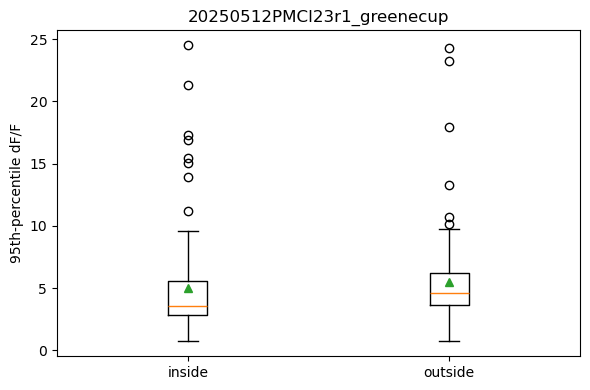

/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup [eps=13, min_samples=50]:
  {'inside': {'n': 111, 'mean': 4.907190149440816, 'median': 4.198589728279898, 'std': 3.1413847883873114}, 'outside': {'n': 111, 'mean': 5.12566625127008, 'median': 4.409813917127296, 'std': 3.1341646156586607}, 'MWU': {'U': 5727.0, 'p': 0.3655155841585347}}



/tmp/ipykernel_114103/155828454.py:128: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


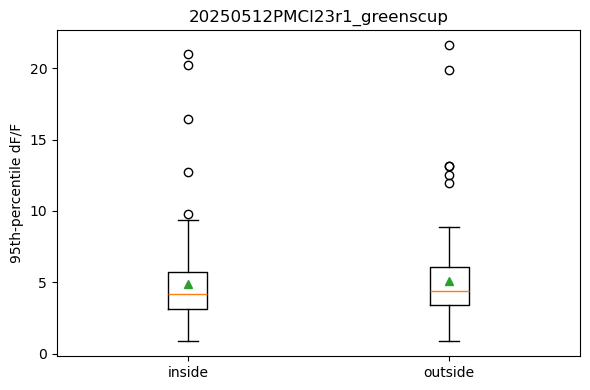

/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup [eps=12, min_samples=50]:
  {'inside': {'n': 109, 'mean': 5.273318726303976, 'median': 4.685876875719865, 'std': 2.875368857072273}, 'outside': {'n': 109, 'mean': 5.666927031755564, 'median': 5.142334070684371, 'std': 3.141888524438435}, 'MWU': {'U': 5403.0, 'p': 0.24881553340134543}}



/tmp/ipykernel_114103/155828454.py:128: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


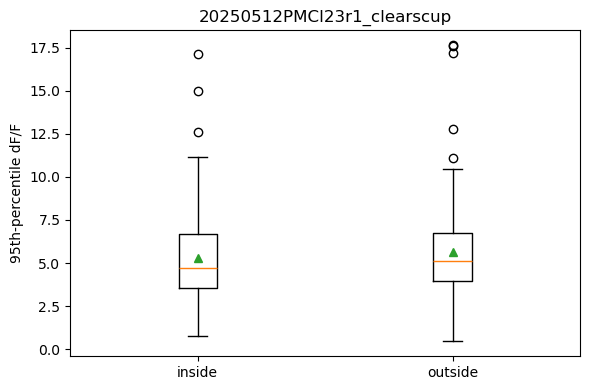

/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearecup [eps=12, min_samples=50]:
  {'inside': {'n': 111, 'mean': 6.713761724167693, 'median': 4.0759513527267, 'std': 19.690064655581892}, 'outside': {'n': 111, 'mean': 7.880834995365212, 'median': 3.9165456950016075, 'std': 30.954248384488928}, 'MWU': {'U': 5973.0, 'p': 0.695943568839583}}



/tmp/ipykernel_114103/155828454.py:128: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


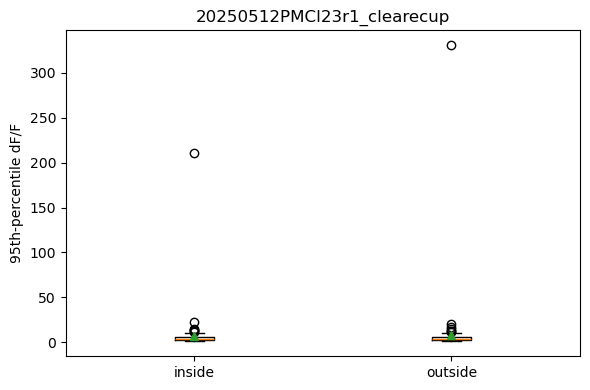

In [44]:
#!/usr/bin/env python3
# For inline plotting in Jupyter
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

import os
import glob
import json
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull
from scipy.optimize import least_squares
from sklearn.cluster import DBSCAN
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

# ——— 1. Load COM with timestamps ———
def load_com_df(rec_path):
    """Return a DataFrame with ['timestamp_ms_mini','com1_x','com1_y']."""
    h5_dir = os.path.join(rec_path, 'MIR_Aligned')
    files = glob.glob(os.path.join(h5_dir, '*aligned_predictions_with_ca_and_dF_F*.h5'))
    if not files:
        raise FileNotFoundError(f"No .h5 in {h5_dir}")
    df = pd.read_hdf(files[0], key='df')
    if df.index.name == 'timestamp_ms_mini':
        df = df.reset_index()
    return df[['timestamp_ms_mini', 'com1_x', 'com1_y']]

# ——— 2. Fit circle to convex hull ———
def fit_circle_hull(pts):
    hull = ConvexHull(pts)
    ph = pts[hull.vertices]
    cx0, cy0 = ph.mean(axis=0)
    r0 = np.mean(np.hypot(ph[:,0]-cx0, ph[:,1]-cy0))
    def resid(p):
        return np.hypot(ph[:,0]-p[0], ph[:,1]-p[1]) - p[2]
    sol = least_squares(resid, x0=(cx0, cy0, r0))
    return sol.x  # xc, yc, r

# ——— 3. Detect main DBSCAN cluster → circle params ———
def detect_region(pts, eps=12, min_samples=50):
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(pts)
    labels = db.labels_
    mask = labels >= 0
    if not mask.any():
        return None, None, None
    labs, counts = np.unique(labels[mask], return_counts=True)
    main = labs[np.argmax(counts)]
    return fit_circle_hull(pts[labels == main])

# ——— 4. Load neural dF/F data ———
def load_neural_df(rec_path):
    """
    Returns a DataFrame with ['timestamp_ms_mini'] + all 'dF_F_roi*' columns.
    """
    h5_dir = os.path.join(rec_path, 'MIR_Aligned')
    files = glob.glob(os.path.join(h5_dir, '*aligned_predictions_with_ca_and_dF_F*.h5'))
    if not files:
        raise FileNotFoundError(f"No .h5 in {h5_dir}")
    df = pd.read_hdf(files[0], key='df')
    if df.index.name == 'timestamp_ms_mini':
        df = df.reset_index()
    roi_cols = [c for c in df.columns if c.startswith('dF_F_roi')]
    return df[['timestamp_ms_mini'] + roi_cols]

# ——— 5. Compute 95th-percentiles inside vs outside → raw arrays ———
def get_in_out_arrays(rec_path, pct=95, eps=12, min_samples=50):
    com = load_com_df(rec_path)
    xc, yc, r = detect_region(com[['com1_x','com1_y']].values, eps, min_samples)
    if xc is None:
        raise RuntimeError(f"No interaction region found in {rec_path}")
    d2 = (com['com1_x'] - xc)**2 + (com['com1_y'] - yc)**2
    com['inside'] = d2 <= r**2

    nd = load_neural_df(rec_path)
    merged = pd.merge(
        nd,
        com[['timestamp_ms_mini', 'inside']],
        on='timestamp_ms_mini',
        how='inner'
    )
    roi_cols = [c for c in merged.columns if c.startswith('dF_F_roi')]
    mat = merged[roi_cols].values.T
    inside_mask  = merged['inside'].values
    outside_mask = ~inside_mask

    stat_in  = np.nanpercentile(mat[:, inside_mask],  pct, axis=1) if inside_mask.any()  else np.array([])
    stat_out = np.nanpercentile(mat[:, outside_mask], pct, axis=1) if outside_mask.any() else np.array([])

    return stat_in, stat_out

# ——— 6. Compute and save stats + MWU → JSON ———
def compare_in_out(rec_path, pct=95, eps=12, min_samples=50):
    stat_in, stat_out = get_in_out_arrays(rec_path, pct, eps, min_samples)

    def desc(a):
        valid = ~np.isnan(a)
        return dict(
            n=int(np.count_nonzero(valid)),
            mean=float(np.nanmean(a))   if valid.any() else float('nan'),
            median=float(np.nanmedian(a)) if valid.any() else float('nan'),
            std=float(np.nanstd(a))     if valid.any() else float('nan'),
        )

    stats = {
        'inside':  desc(stat_in),
        'outside': desc(stat_out),
    }
    if stat_in.size and stat_out.size:
        u, p = mannwhitneyu(stat_in, stat_out, alternative='two-sided')
        stats['MWU'] = {'U': float(u), 'p': float(p)}
    else:
        stats['MWU'] = None

    # still save JSON if you want
    out = os.path.join(rec_path, 'vis')
    os.makedirs(out, exist_ok=True)
    with open(os.path.join(out, 'in_out_stats.json'), 'w') as f:
        json.dump(stats, f, indent=2)

    return stats

# ——— 7. Plot boxplot of inside vs outside inline ———
def plot_in_out_boxplot(rec_path, pct=95, eps=12, min_samples=50):
    stat_in, stat_out = get_in_out_arrays(rec_path, pct, eps, min_samples)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot(
        [stat_in, stat_out],
        labels=['inside', 'outside'],
        showmeans=True
    )
    ax.set_ylabel(f'{pct}th-percentile dF/F')
    ax.set_title(os.path.basename(rec_path))
    fig.tight_layout()
    plt.show()
    return fig

# ——— Main: run per-session and display plots ———
if __name__ == '__main__':
    exclude_json = '/home/lq53/mir_repos/BBOP/random_tests/25feb_more_corr_explo/neuro_exclude.json'
    with open(exclude_json) as f:
        exclude_mapping = json.load(f)

    sessions = [
        ("/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup", 10, 50),
        ("/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup",   13, 50),
        ("/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup",  12, 50),
        ("/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearecup",  12, 50),
    ]

    for sess, eps, ms in sessions:
        try:
            stats = compare_in_out(sess, pct=95, eps=eps, min_samples=ms)
            print(f"{sess} [eps={eps}, min_samples={ms}]:\n  {stats}\n")
            plot_in_out_boxplot(sess, pct=95, eps=eps, min_samples=ms)
        except Exception as e:
            print(f"Error on {sess} [eps={eps}, min_samples={ms}]: {e}")


In [ ]:
#!/usr/bin/env python3
# For inline plotting in Jupyter
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

import os
import glob
import json
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull
from scipy.optimize import least_squares
from sklearn.cluster import DBSCAN
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

# ——— 1. Load COM with timestamps ———
def load_com_df(rec_path):
    """Return a DataFrame with ['timestamp_ms_mini','com1_x','com1_y']."""
    h5_dir = os.path.join(rec_path, 'MIR_Aligned')
    files = glob.glob(os.path.join(h5_dir, '*aligned_predictions_with_ca_and_dF_F*.h5'))
    if not files:
        raise FileNotFoundError(f"No .h5 in {h5_dir}")
    df = pd.read_hdf(files[0], key='df')
    if df.index.name == 'timestamp_ms_mini':
        df = df.reset_index()
    return df[['timestamp_ms_mini', 'com1_x', 'com1_y']]

# ——— 2. Fit circle to convex hull ———
def fit_circle_hull(pts):
    hull = ConvexHull(pts)
    ph = pts[hull.vertices]
    cx0, cy0 = ph.mean(axis=0)
    r0 = np.mean(np.hypot(ph[:,0]-cx0, ph[:,1]-cy0))
    def resid(p):
        return np.hypot(ph[:,0]-p[0], ph[:,1]-p[1]) - p[2]
    sol = least_squares(resid, x0=(cx0, cy0, r0))
    return sol.x  # xc, yc, r

# ——— 3. Detect main DBSCAN cluster → circle params ———
def detect_region(pts, eps=12, min_samples=50):
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(pts)
    labels = db.labels_
    mask = labels >= 0
    if not mask.any():
        return None, None, None
    labs, counts = np.unique(labels[mask], return_counts=True)
    main = labs[np.argmax(counts)]
    return fit_circle_hull(pts[labels == main])

# ——— 4. Load neural dF/F data ———
def load_neural_df(rec_path):
    """
    Returns a DataFrame with ['timestamp_ms_mini'] + all 'dF_F_roi*' columns.
    """
    h5_dir = os.path.join(rec_path, 'MIR_Aligned')
    files = glob.glob(os.path.join(h5_dir, '*aligned_predictions_with_ca_and_dF_F*.h5'))
    if not files:
        raise FileNotFoundError(f"No .h5 in {h5_dir}")
    df = pd.read_hdf(files[0], key='df')
    if df.index.name == 'timestamp_ms_mini':
        df = df.reset_index()
    roi_cols = [c for c in df.columns if c.startswith('dF_F_roi')]
    return df[['timestamp_ms_mini'] + roi_cols]

# ——— 5. Compute 95th-percentiles inside vs outside → raw arrays ———
def get_in_out_arrays(rec_path, pct=95, eps=12, min_samples=50):
    com = load_com_df(rec_path)
    xc, yc, r = detect_region(com[['com1_x','com1_y']].values, eps, min_samples)
    if xc is None:
        raise RuntimeError(f"No interaction region found in {rec_path}")
    d2 = (com['com1_x'] - xc)**2 + (com['com1_y'] - yc)**2
    com['inside'] = d2 <= r**2

    nd = load_neural_df(rec_path)
    merged = pd.merge(
        nd,
        com[['timestamp_ms_mini', 'inside']],
        on='timestamp_ms_mini',
        how='inner'
    )
    roi_cols = [c for c in merged.columns if c.startswith('dF_F_roi')]
    mat = merged[roi_cols].values.T
    inside_mask  = merged['inside'].values
    outside_mask = ~inside_mask

    stat_in  = np.nanpercentile(mat[:, inside_mask],  pct, axis=1) if inside_mask.any()  else np.array([])
    stat_out = np.nanpercentile(mat[:, outside_mask], pct, axis=1) if outside_mask.any() else np.array([])

    return stat_in, stat_out

# ——— 6. Compute and save stats + MWU → JSON ———
def compare_in_out(rec_path, pct=95, eps=12, min_samples=50):
    stat_in, stat_out = get_in_out_arrays(rec_path, pct, eps, min_samples)

    def desc(a):
        valid = ~np.isnan(a)
        return dict(
            n=int(np.count_nonzero(valid)),
            mean=float(np.nanmean(a))   if valid.any() else float('nan'),
            median=float(np.nanmedian(a)) if valid.any() else float('nan'),
            std=float(np.nanstd(a))     if valid.any() else float('nan'),
        )

    stats = {
        'inside':  desc(stat_in),
        'outside': desc(stat_out),
    }
    if stat_in.size and stat_out.size:
        u, p = mannwhitneyu(stat_in, stat_out, alternative='two-sided')
        stats['MWU'] = {'U': float(u), 'p': float(p)}
    else:
        stats['MWU'] = None

    # still save JSON if you want
    out = os.path.join(rec_path, 'vis')
    os.makedirs(out, exist_ok=True)
    with open(os.path.join(out, 'in_out_stats.json'), 'w') as f:
        json.dump(stats, f, indent=2)

    return stats

# ——— 7. Plot boxplot of inside vs outside inline ———
def plot_in_out_boxplot(rec_path, pct=95, eps=12, min_samples=50):
    stat_in, stat_out = get_in_out_arrays(rec_path, pct, eps, min_samples)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot(
        [stat_in, stat_out],
        labels=['inside', 'outside'],
        showmeans=True
    )
    ax.set_ylabel(f'{pct}th-percentile dF/F')
    ax.set_title(os.path.basename(rec_path))
    fig.tight_layout()
    plt.show()
    return fig

# ——— Main: run per-session and display plots ———
if __name__ == '__main__':
    exclude_json = '/home/lq53/mir_repos/BBOP/random_tests/25feb_more_corr_explo/neuro_exclude.json'
    with open(exclude_json) as f:
        exclude_mapping = json.load(f)

    sessions = [
        ("/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup", 10, 50),
        ("/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup",   13, 50),
        ("/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup",  12, 50),
        ("/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearecup",  12, 50),
    ]

    for sess, eps, ms in sessions:
        try:
            stats = compare_in_out(sess, pct=95, eps=eps, min_samples=ms)
            print(f"{sess} [eps={eps}, min_samples={ms}]:\n  {stats}\n")
            plot_in_out_boxplot(sess, pct=95, eps=eps, min_samples=ms)
        except Exception as e:
            print(f"Error on {sess} [eps={eps}, min_samples={ms}]: {e}")



--- Descriptive Stats ---
green empty cup      n= 100, mean=5.477, std=3.795, med=4.135
green social cup     n= 105, mean=5.272, std=2.999, med=4.488
clear social cup     n= 103, mean=5.802, std=2.799, med=4.909
clear empty cup      n= 105, mean=7.558, std=25.271, med=4.295

--- Pairwise Mann–Whitney U ---
green empty cup      vs green social cup     U=4991.0, p=0.5426
green empty cup      vs clear social cup     U=4096.0, p=0.0118
green empty cup      vs clear empty cup      U=5501.0, p=0.5552
green social cup     vs clear social cup     U=4549.0, p=0.0480
green social cup     vs clear empty cup      U=5972.0, p=0.2972
clear social cup     vs clear empty cup      U=6572.0, p=0.0073


/tmp/ipykernel_39772/3760462092.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


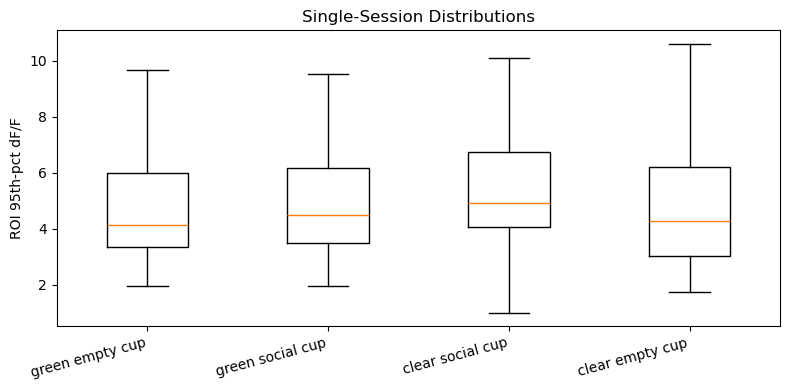

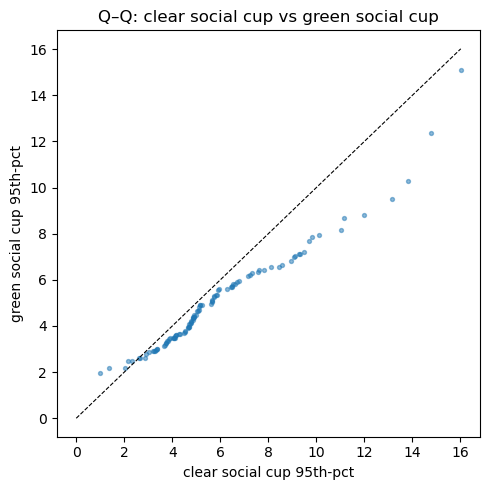


Done.


In [ ]:
#!/usr/bin/env python3
"""
Standalone script to compute and visualize 95th-percentile comparisons
across four independent “single”-session groups.
"""

import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ----------------------------------------------------------------------------
# 1. Exclusion dict & HDF5 loader (unchanged)
# ----------------------------------------------------------------------------
exclude_json_path = '/home/lq53/mir_repos/BBOP/random_tests/25feb_more_corr_explo/neuro_exclude.json'
with open(exclude_json_path, 'r') as f:
    exclude_mapping = json.load(f)

def get_excluded_neurons_for_session(session_path, exclude_dict):
    if not isinstance(exclude_dict, dict):
        return []
    if session_path in exclude_dict:
        return exclude_dict[session_path]
    for key, val in exclude_dict.items():
        if key in session_path:
            return val
    return []

def load_session_data(rec_path):
    h5_dir = os.path.join(rec_path, 'MIR_Aligned')
    pattern = '*aligned_predictions_with_ca_and_dF_F*.h5'
    h5_files = glob.glob(os.path.join(h5_dir, pattern))
    if not h5_files:
        raise FileNotFoundError(f"No .h5 found in {h5_dir}")
    df = pd.read_hdf(h5_files[0], key='df')
    if df.index.name == 'timestamp_ms_mini':
        df = df.reset_index()
    df['session_path'] = rec_path
    return df

# ----------------------------------------------------------------------------
# 2. Build neuron×frame matrix, drop excluded & low-variance ROIs
# ----------------------------------------------------------------------------
def build_neuron_matrix_raw(df, exclude_dict):
    sess = df['session_path'].iloc[0]
    excluded = get_excluded_neurons_for_session(sess, exclude_dict)
    all_names = [c for c in df.columns if c.startswith('dF_F_roi')]
    keep = []
    for c in all_names:
        try:
            idx = int(c.split('_')[-1][3:])
        except:
            continue
        if idx not in excluded:
            keep.append(c)
    if not keep:
        return [], np.zeros((0, len(df)))
    mat = df[keep].values.T
    variances = np.var(mat, axis=1)
    cutoff = np.percentile(variances, 5) if variances.size else 0
    mask = variances > cutoff
    return [keep[i] for i in range(len(keep)) if mask[i]], mat[mask]

# ----------------------------------------------------------------------------
# 3. Single-session 95th-pct extractor
# ----------------------------------------------------------------------------
def get_single_stats(rec_path, exclude_dict, pct=95):
    df = load_session_data(rec_path)
    names, mat = build_neuron_matrix_raw(df, exclude_dict)
    if mat.size == 0:
        return [], np.array([])
    return names, np.nanpercentile(mat, pct, axis=1)

def aggregate_single_stats(session_list, exclude_dict, pct=95):
    all_vals = []
    for p in session_list:
        try:
            _, vals = get_single_stats(p, exclude_dict, pct)
        except Exception as e:
            print(f" Skipping {p}: {e}")
            continue
        valid = ~np.isnan(vals)
        all_vals.extend(vals[valid].tolist())
    return np.array(all_vals)

# ----------------------------------------------------------------------------
# 4. Descriptive + Mann–Whitney reporting
# ----------------------------------------------------------------------------
def desc(arr):
    return {
        'n':      int(np.count_nonzero(~np.isnan(arr))),
        'mean':   float(np.nanmean(arr)),
        'std':    float(np.nanstd(arr)),
        'median': float(np.nanmedian(arr))
    }

def print_stats(label, arr):
    s = desc(arr)
    print(f"{label:8} n={s['n']:4}, mean={s['mean']:.3f}, std={s['std']:.3f}, med={s['median']:.3f}")

def compare(name1, a1, name2, a2):
    if a1.size and a2.size:
        u, p = mannwhitneyu(a1, a2, alternative='two-sided')
        print(f"{name1} vs {name2:8} U={u:.1f}, p={p:.4f}")
    else:
        print(f"{name1} vs {name2:8} insufficient data")

# ----------------------------------------------------------------------------
# 5. Plotting
# ----------------------------------------------------------------------------
def plot_boxplot(group_dict):
    labels, data = zip(*group_dict.items())
    plt.figure(figsize=(6,4))
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.ylabel("ROI 95th-pct dF/F")
    plt.title("Single-Session Distributions")
    plt.tight_layout()
    plt.show()

def plot_qq(name1, a1, name2, a2):
    n = min(len(a1), len(a2))
    x = np.sort(a1)[:n]
    y = np.sort(a2)[:n]
    mx = max(x.max(), y.max())
    plt.figure(figsize=(4,4))
    plt.scatter(x, y, s=8, alpha=0.5)
    plt.plot([0,mx],[0,mx], 'k--', lw=0.8)
    plt.xlabel(f"{name1} 95th-pct")
    plt.ylabel(f"{name2} 95th-pct")
    plt.title(f"Q–Q: {name1} vs {name2}")
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------------------------
# 6. Main: define your four session-lists here
# ----------------------------------------------------------------------------
if __name__ == "__main__":
    pct = 95

    # define your four session‐lists with descriptive labels:
    session_groups = {
        "green empty cup": [
            "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup"
        ],
        "green social cup": [
            "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup"
        ],
        "clear social cup": [
            "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup"
        ],
        "clear empty cup": [
            "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearecup"
        ],
    }

    # aggregate stats under the new names:
    groups = {
        label: aggregate_single_stats(paths, exclude_mapping, pct)
        for label, paths in session_groups.items()
    }

    # descriptive stats now print with full labels:
    print("\n--- Descriptive Stats ---")
    for label, arr in groups.items():
        print_stats(label, arr)

    # pairwise comparisons also use the descriptive labels:
    print("\n--- Pairwise Mann–Whitney U ---")
    labels = list(groups.keys())
    for i in range(len(labels)):
        for j in range(i+1, len(labels)):
            compare(labels[i], groups[labels[i]],
                    labels[j], groups[labels[j]])

    # boxplot with full names on the x‐axis:
    plot_boxplot(groups)

    # example Q–Q between “green empty cup” and “green social cup”:
    plot_qq("green empty cup",
            groups["green empty cup"],
            "green social cup",
            groups["green social cup"])

    print("\nDone.")




--- Descriptive Stats ---
green empty cup n= 256, mean=4.817, std=3.004, med=3.930
green social cup n= 290, mean=3.901, std=2.224, med=3.404
clear social cup n= 200, mean=4.425, std=2.538, med=3.733
clear empty cup n= 273, mean=4.966, std=15.960, med=3.215

--- Pairwise Mann–Whitney U ---
green empty cup vs green social cup U=46373.0, p=0.0000
green empty cup vs clear social cup U=28290.0, p=0.0541
green empty cup vs clear empty cup U=44495.0, p=0.0000
green social cup vs clear social cup U=25459.0, p=0.0215
green social cup vs clear empty cup U=40902.0, p=0.4949
clear social cup vs clear empty cup U=31192.0, p=0.0081


/tmp/ipykernel_114103/2756688484.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


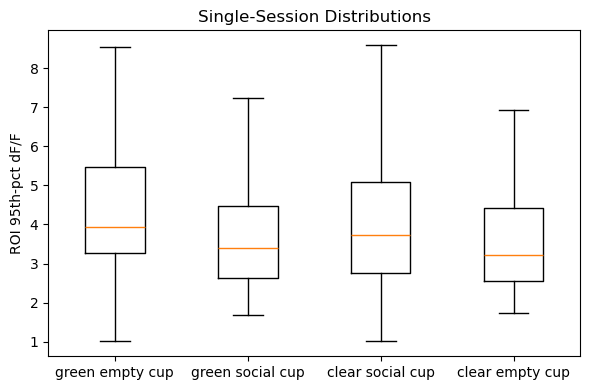

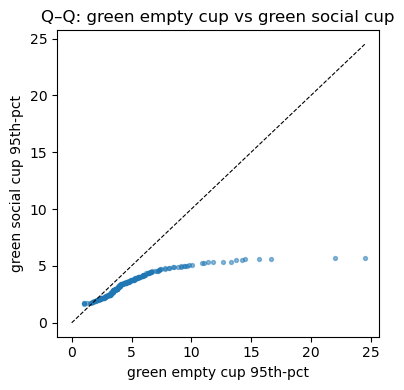


Done.


In [42]:
#!/usr/bin/env python3
"""
Standalone script to compute and visualize 95th-percentile comparisons
across four independent “single”-session groups.
"""

import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ----------------------------------------------------------------------------
# 1. Exclusion dict & HDF5 loader (unchanged)
# ----------------------------------------------------------------------------
exclude_json_path = '/home/lq53/mir_repos/BBOP/random_tests/25feb_more_corr_explo/neuro_exclude.json'
with open(exclude_json_path, 'r') as f:
    exclude_mapping = json.load(f)

def get_excluded_neurons_for_session(session_path, exclude_dict):
    if not isinstance(exclude_dict, dict):
        return []
    if session_path in exclude_dict:
        return exclude_dict[session_path]
    for key, val in exclude_dict.items():
        if key in session_path:
            return val
    return []

def load_session_data(rec_path):
    h5_dir = os.path.join(rec_path, 'MIR_Aligned')
    pattern = '*aligned_predictions_with_ca_and_dF_F*.h5'
    h5_files = glob.glob(os.path.join(h5_dir, pattern))
    if not h5_files:
        raise FileNotFoundError(f"No .h5 found in {h5_dir}")
    df = pd.read_hdf(h5_files[0], key='df')
    if df.index.name == 'timestamp_ms_mini':
        df = df.reset_index()
    df['session_path'] = rec_path
    return df

# ----------------------------------------------------------------------------
# 2. Build neuron×frame matrix, drop excluded & low-variance ROIs
# ----------------------------------------------------------------------------
def build_neuron_matrix_raw(df, exclude_dict):
    sess = df['session_path'].iloc[0]
    excluded = get_excluded_neurons_for_session(sess, exclude_dict)
    all_names = [c for c in df.columns if c.startswith('dF_F_roi')]
    keep = []
    for c in all_names:
        try:
            idx = int(c.split('_')[-1][3:])
        except:
            continue
        if idx not in excluded:
            keep.append(c)
    if not keep:
        return [], np.zeros((0, len(df)))
    mat = df[keep].values.T
    variances = np.var(mat, axis=1)
    cutoff = np.percentile(variances, 5) if variances.size else 0
    mask = variances > cutoff
    return [keep[i] for i in range(len(keep)) if mask[i]], mat[mask]

# ----------------------------------------------------------------------------
# 3. Single-session 95th-pct extractor
# ----------------------------------------------------------------------------
def get_single_stats(rec_path, exclude_dict, pct=95):
    df = load_session_data(rec_path)
    names, mat = build_neuron_matrix_raw(df, exclude_dict)
    if mat.size == 0:
        return [], np.array([])
    return names, np.nanpercentile(mat, pct, axis=1)

def aggregate_single_stats(session_list, exclude_dict, pct=95):
    all_vals = []
    for p in session_list:
        try:
            _, vals = get_single_stats(p, exclude_dict, pct)
        except Exception as e:
            print(f" Skipping {p}: {e}")
            continue
        valid = ~np.isnan(vals)
        all_vals.extend(vals[valid].tolist())
    return np.array(all_vals)

# ----------------------------------------------------------------------------
# 4. Descriptive + Mann–Whitney reporting
# ----------------------------------------------------------------------------
def desc(arr):
    return {
        'n':      int(np.count_nonzero(~np.isnan(arr))),
        'mean':   float(np.nanmean(arr)),
        'std':    float(np.nanstd(arr)),
        'median': float(np.nanmedian(arr))
    }

def print_stats(label, arr):
    s = desc(arr)
    print(f"{label:8} n={s['n']:4}, mean={s['mean']:.3f}, std={s['std']:.3f}, med={s['median']:.3f}")

def compare(name1, a1, name2, a2):
    if a1.size and a2.size:
        u, p = mannwhitneyu(a1, a2, alternative='two-sided')
        print(f"{name1} vs {name2:8} U={u:.1f}, p={p:.4f}")
    else:
        print(f"{name1} vs {name2:8} insufficient data")

# ----------------------------------------------------------------------------
# 5. Plotting
# ----------------------------------------------------------------------------
def plot_boxplot(group_dict):
    labels, data = zip(*group_dict.items())
    plt.figure(figsize=(6,4))
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.ylabel("ROI 95th-pct dF/F")
    plt.title("Single-Session Distributions")
    plt.tight_layout()
    plt.show()

def plot_qq(name1, a1, name2, a2):
    n = min(len(a1), len(a2))
    x = np.sort(a1)[:n]
    y = np.sort(a2)[:n]
    mx = max(x.max(), y.max())
    plt.figure(figsize=(4,4))
    plt.scatter(x, y, s=8, alpha=0.5)
    plt.plot([0,mx],[0,mx], 'k--', lw=0.8)
    plt.xlabel(f"{name1} 95th-pct")
    plt.ylabel(f"{name2} 95th-pct")
    plt.title(f"Q–Q: {name1} vs {name2}")
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------------------------
# 6. Main: define your four session-lists here
# ----------------------------------------------------------------------------
if __name__ == "__main__":
    pct = 95

    # define your four session‐lists with descriptive labels:
    session_groups = {
        "green empty cup": [
            "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup",
            "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_greenecup"
        ],
        "green social cup": [
            "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup",
            "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_greenscup"
        ],
        "clear social cup": [
            "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup",
            "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_clearscup"
        ],
        "clear empty cup": [
            "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearecup",
            "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_clearecup"
        ],
    }

    # aggregate stats under the new names:
    groups = {
        label: aggregate_single_stats(paths, exclude_mapping, pct)
        for label, paths in session_groups.items()
    }

    # descriptive stats now print with full labels:
    print("\n--- Descriptive Stats ---")
    for label, arr in groups.items():
        print_stats(label, arr)

    # pairwise comparisons also use the descriptive labels:
    print("\n--- Pairwise Mann–Whitney U ---")
    labels = list(groups.keys())
    for i in range(len(labels)):
        for j in range(i+1, len(labels)):
            compare(labels[i], groups[labels[i]],
                    labels[j], groups[labels[j]])

    # boxplot with full names on the x‐axis:
    plot_boxplot(groups)

    # example Q–Q between “green empty cup” and “green social cup”:
    plot_qq("green empty cup",
            groups["green empty cup"],
            "green social cup",
            groups["green social cup"])

    print("\nDone.")




--- Descriptive Stats ---
green empty cup n= 156, mean=4.394, std=2.263, med=3.741
green social cup n= 185, mean=3.123, std=0.988, med=2.905
clear social cup n=  97, mean=2.963, std=0.904, med=2.874
clear empty cup n= 168, mean=3.346, std=2.823, med=2.867

--- Pairwise Mann–Whitney U ---
green empty cup vs green social cup U=20427.0, p=0.0000
green empty cup vs clear social cup U=11190.0, p=0.0000
green empty cup vs clear empty cup U=18527.0, p=0.0000
green social cup vs clear social cup U=9716.0, p=0.2534
green social cup vs clear empty cup U=15717.0, p=0.8538
clear social cup vs clear empty cup U=7552.0, p=0.3218


/tmp/ipykernel_114103/1213823360.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


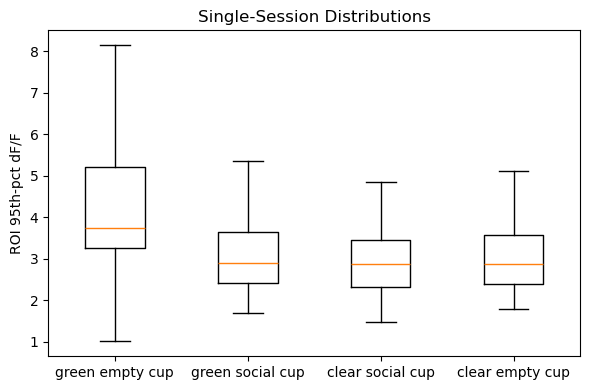

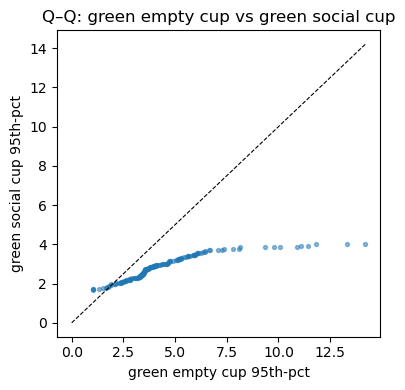


Done.


In [43]:
#!/usr/bin/env python3
"""
Standalone script to compute and visualize 95th-percentile comparisons
across four independent “single”-session groups.
"""

import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ----------------------------------------------------------------------------
# 1. Exclusion dict & HDF5 loader (unchanged)
# ----------------------------------------------------------------------------
exclude_json_path = '/home/lq53/mir_repos/BBOP/random_tests/25feb_more_corr_explo/neuro_exclude.json'
with open(exclude_json_path, 'r') as f:
    exclude_mapping = json.load(f)

def get_excluded_neurons_for_session(session_path, exclude_dict):
    if not isinstance(exclude_dict, dict):
        return []
    if session_path in exclude_dict:
        return exclude_dict[session_path]
    for key, val in exclude_dict.items():
        if key in session_path:
            return val
    return []

def load_session_data(rec_path):
    h5_dir = os.path.join(rec_path, 'MIR_Aligned')
    pattern = '*aligned_predictions_with_ca_and_dF_F*.h5'
    h5_files = glob.glob(os.path.join(h5_dir, pattern))
    if not h5_files:
        raise FileNotFoundError(f"No .h5 found in {h5_dir}")
    df = pd.read_hdf(h5_files[0], key='df')
    if df.index.name == 'timestamp_ms_mini':
        df = df.reset_index()
    df['session_path'] = rec_path
    return df

# ----------------------------------------------------------------------------
# 2. Build neuron×frame matrix, drop excluded & low-variance ROIs
# ----------------------------------------------------------------------------
def build_neuron_matrix_raw(df, exclude_dict):
    sess = df['session_path'].iloc[0]
    excluded = get_excluded_neurons_for_session(sess, exclude_dict)
    all_names = [c for c in df.columns if c.startswith('dF_F_roi')]
    keep = []
    for c in all_names:
        try:
            idx = int(c.split('_')[-1][3:])
        except:
            continue
        if idx not in excluded:
            keep.append(c)
    if not keep:
        return [], np.zeros((0, len(df)))
    mat = df[keep].values.T
    variances = np.var(mat, axis=1)
    cutoff = np.percentile(variances, 5) if variances.size else 0
    mask = variances > cutoff
    return [keep[i] for i in range(len(keep)) if mask[i]], mat[mask]

# ----------------------------------------------------------------------------
# 3. Single-session 95th-pct extractor
# ----------------------------------------------------------------------------
def get_single_stats(rec_path, exclude_dict, pct=95):
    df = load_session_data(rec_path)
    names, mat = build_neuron_matrix_raw(df, exclude_dict)
    if mat.size == 0:
        return [], np.array([])
    return names, np.nanpercentile(mat, pct, axis=1)

def aggregate_single_stats(session_list, exclude_dict, pct=95):
    all_vals = []
    for p in session_list:
        try:
            _, vals = get_single_stats(p, exclude_dict, pct)
        except Exception as e:
            print(f" Skipping {p}: {e}")
            continue
        valid = ~np.isnan(vals)
        all_vals.extend(vals[valid].tolist())
    return np.array(all_vals)

# ----------------------------------------------------------------------------
# 4. Descriptive + Mann–Whitney reporting
# ----------------------------------------------------------------------------
def desc(arr):
    return {
        'n':      int(np.count_nonzero(~np.isnan(arr))),
        'mean':   float(np.nanmean(arr)),
        'std':    float(np.nanstd(arr)),
        'median': float(np.nanmedian(arr))
    }

def print_stats(label, arr):
    s = desc(arr)
    print(f"{label:8} n={s['n']:4}, mean={s['mean']:.3f}, std={s['std']:.3f}, med={s['median']:.3f}")

def compare(name1, a1, name2, a2):
    if a1.size and a2.size:
        u, p = mannwhitneyu(a1, a2, alternative='two-sided')
        print(f"{name1} vs {name2:8} U={u:.1f}, p={p:.4f}")
    else:
        print(f"{name1} vs {name2:8} insufficient data")

# ----------------------------------------------------------------------------
# 5. Plotting
# ----------------------------------------------------------------------------
def plot_boxplot(group_dict):
    labels, data = zip(*group_dict.items())
    plt.figure(figsize=(6,4))
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.ylabel("ROI 95th-pct dF/F")
    plt.title("Single-Session Distributions")
    plt.tight_layout()
    plt.show()

def plot_qq(name1, a1, name2, a2):
    n = min(len(a1), len(a2))
    x = np.sort(a1)[:n]
    y = np.sort(a2)[:n]
    mx = max(x.max(), y.max())
    plt.figure(figsize=(4,4))
    plt.scatter(x, y, s=8, alpha=0.5)
    plt.plot([0,mx],[0,mx], 'k--', lw=0.8)
    plt.xlabel(f"{name1} 95th-pct")
    plt.ylabel(f"{name2} 95th-pct")
    plt.title(f"Q–Q: {name1} vs {name2}")
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------------------------
# 6. Main: define your four session-lists here
# ----------------------------------------------------------------------------
if __name__ == "__main__":
    pct = 95

    # define your four session‐lists with descriptive labels:
    session_groups = {
        "green empty cup": [
            # "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup",
            "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_greenecup"
        ],
        "green social cup": [
            # "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup",
            "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_greenscup"
        ],
        "clear social cup": [
            # "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup",
            "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_clearscup"
        ],
        "clear empty cup": [
            # "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearecup",
            "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_clearecup"
        ],
    }

    # aggregate stats under the new names:
    groups = {
        label: aggregate_single_stats(paths, exclude_mapping, pct)
        for label, paths in session_groups.items()
    }

    # descriptive stats now print with full labels:
    print("\n--- Descriptive Stats ---")
    for label, arr in groups.items():
        print_stats(label, arr)

    # pairwise comparisons also use the descriptive labels:
    print("\n--- Pairwise Mann–Whitney U ---")
    labels = list(groups.keys())
    for i in range(len(labels)):
        for j in range(i+1, len(labels)):
            compare(labels[i], groups[labels[i]],
                    labels[j], groups[labels[j]])

    # boxplot with full names on the x‐axis:
    plot_boxplot(groups)

    # example Q–Q between “green empty cup” and “green social cup”:
    plot_qq("green empty cup",
            groups["green empty cup"],
            "green social cup",
            groups["green social cup"])

    print("\nDone.")



Plotting session (all neurons) from: /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup


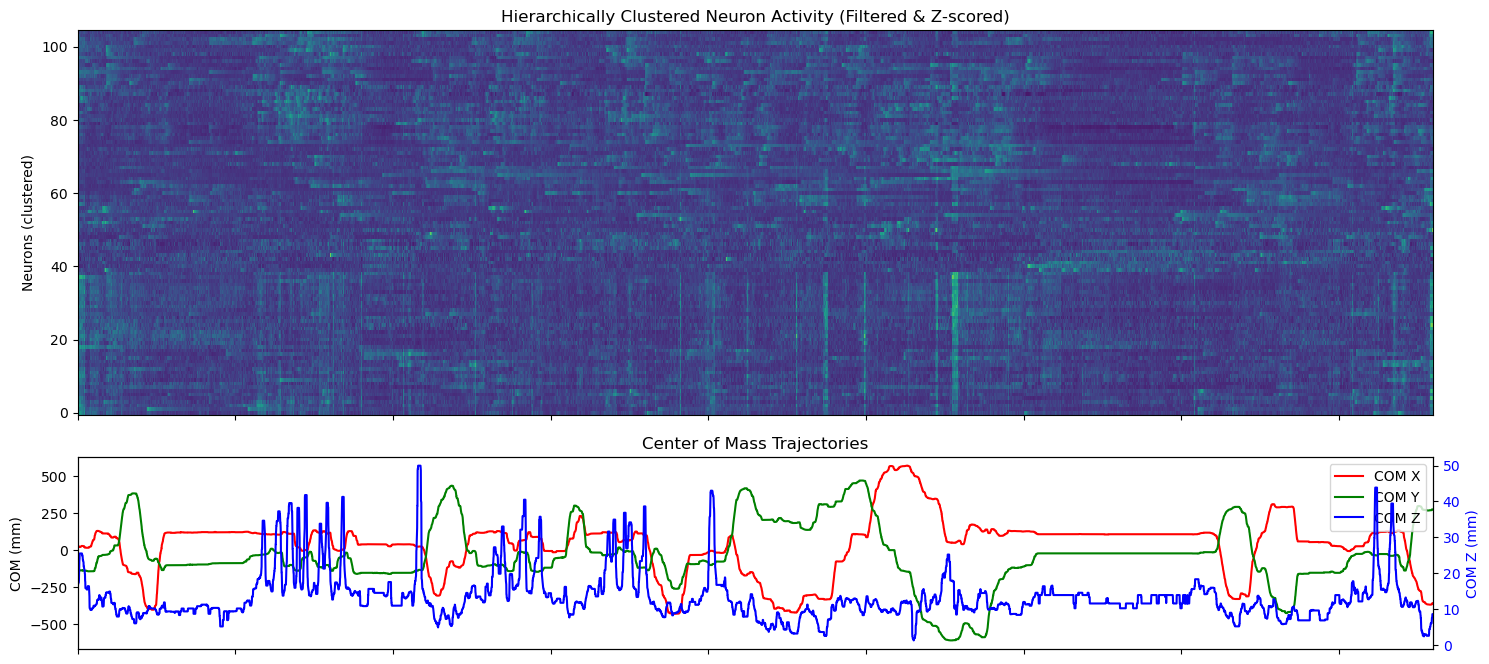

Plotting session (all neurons) from: /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup


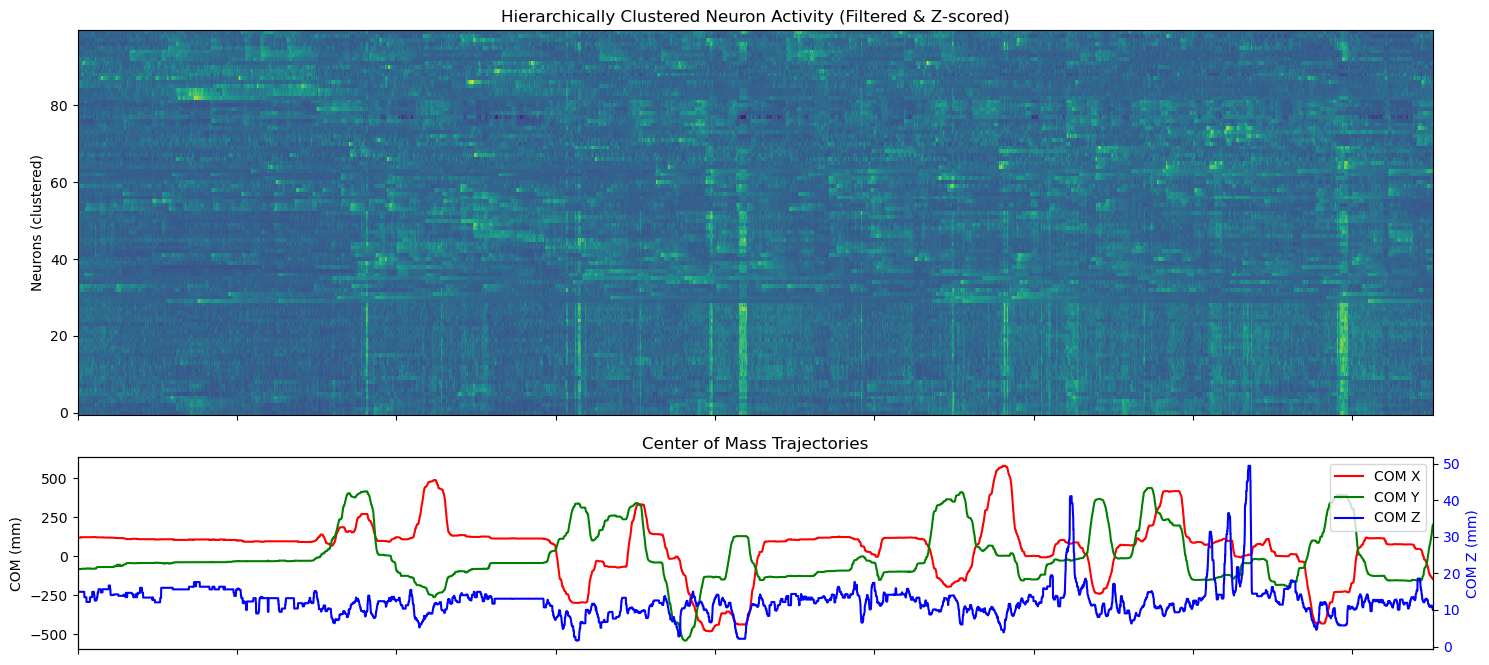

Plotting session (all neurons) from: /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup


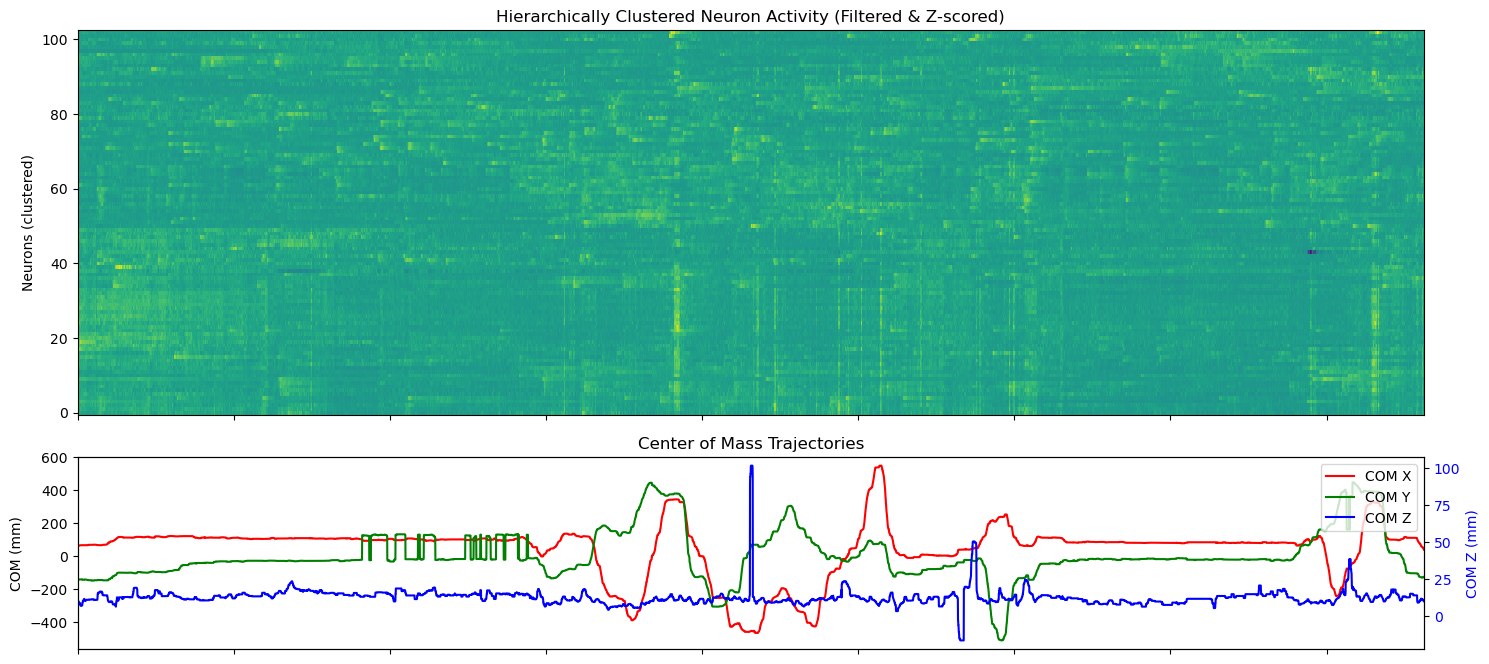

Plotting session (all neurons) from: /data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearecup


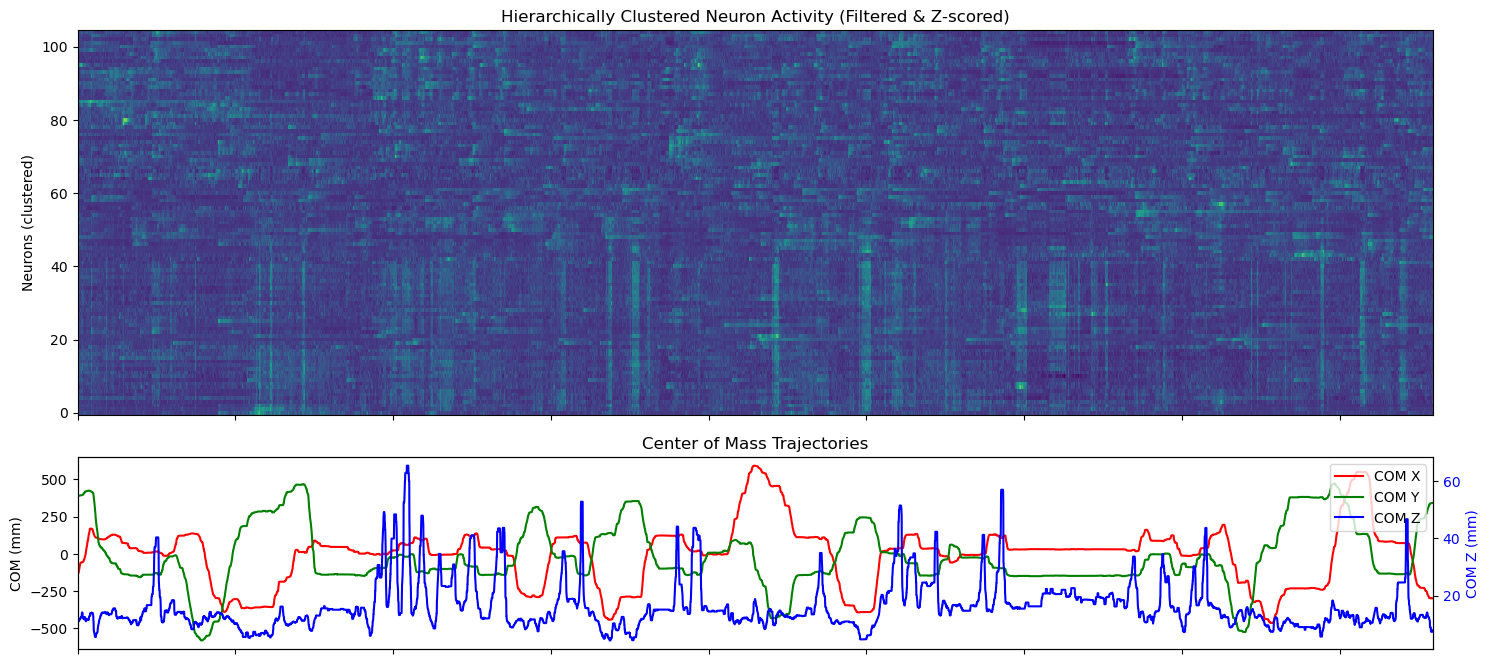

In [5]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import zscore
import glob

# ------------------------------------------------------------------------------
# 1. Load the JSON file with excluded neurons mapping
# ------------------------------------------------------------------------------
exclude_json_path = '/home/lq53/mir_repos/BBOP/random_tests/25feb_more_corr_explo/neuro_exclude.json'
with open(exclude_json_path, 'r') as f:
    exclude_dict = json.load(f)

def get_excluded_neurons_for_session(session_path, exclude_dict):
    """
    Given a session path and the exclusion dictionary loaded from JSON,
    return the list of excluded neuron indices.
    If an exact match is not found, try to match by substring.
    """
    if session_path in exclude_dict:
        return exclude_dict[session_path]
    for key, val in exclude_dict.items():
        if key in session_path:
            return val
    return []  # Default to no exclusions if not found

# ------------------------------------------------------------------------------
# 2. Data Loading with Metadata
# ------------------------------------------------------------------------------
# def load_session_data(rec_path):
#     """
#     Load a single session's HDF5 file, parse the folder structure to extract metadata,
#     and return the resulting DataFrame with added metadata columns.
    
#     Example of the folder structure:
#       /data/big_rim/rsync_dcc_sum/Oct3V1/2024_10_25/20241002PMCr2_15_42

#     Where:
#       - session_id   = 20241002PMCr2_15_42  (last directory)
#       - recording_date = 2024_10_25        (parent directory)
#       - experiment   = Oct3V1              (grandparent directory)
#     """
#     hdf5_file_path = os.path.join(rec_path, 'MIR_Aligned', 'aligned_predictions_with_ca_and_dF_F.h5')
#     df = pd.read_hdf(hdf5_file_path, key='df')
    
#     norm_path = os.path.normpath(rec_path)
#     session_id = os.path.basename(norm_path)
#     recording_date = os.path.basename(os.path.dirname(norm_path))
#     experiment_name = os.path.basename(os.path.dirname(os.path.dirname(norm_path)))
    
#     df['session_id'] = session_id
#     df['recording_date'] = recording_date
#     df['experiment'] = experiment_name
#     df['session_path'] = rec_path
#     df['file_path'] = hdf5_file_path
    
#     return df

def load_session_data(rec_path):
    h5_dir = os.path.join(rec_path, 'MIR_Aligned')
    pattern = '*aligned_predictions_with_ca_and_dF_F*.h5'
    h5_files = glob.glob(os.path.join(h5_dir, pattern))
    if not h5_files:
        raise FileNotFoundError(f"No .h5 found in {h5_dir}")
    df = pd.read_hdf(h5_files[0], key='df')
    if df.index.name == 'timestamp_ms_mini':
        df = df.reset_index()
    df['session_path'] = rec_path
    return df

# ------------------------------------------------------------------------------
# 3. Processing Neuron Activity Data with Optional Exclusion
# ------------------------------------------------------------------------------
def process_neuron_activity(df, exclude_dict=None, manual_exclude_indices=None, apply_exclusion=True):
    """
    Process neuron activity data:
      - Optionally exclude specific neurons.
      - Remove low-variance neurons.
      - Z-score normalize each neuron's time course.
    
    Parameters:
      - df: DataFrame with neuron activity and metadata.
      - exclude_dict: Dictionary from the JSON mapping (optional).
      - manual_exclude_indices: List of neuron indices to exclude manually (optional).
      - apply_exclusion: If False, skip neuron exclusion.
    
    Returns:
      - neuron_activity_normalized: np.array of shape (neurons, timepoints)
      - filtered_neuron_columns: list of neuron column names after filtering
      - df_new: reset-index DataFrame used for plotting (should contain timestamp info)
    """
    # Determine which neurons to exclude
    if apply_exclusion:
        if manual_exclude_indices is not None:
            excluded_indices = manual_exclude_indices
        elif exclude_dict is not None:
            session_path = df['session_path'].iloc[0]
            excluded_indices = get_excluded_neurons_for_session(session_path, exclude_dict)
        else:
            excluded_indices = []
    else:
        excluded_indices = []
    
    # Build the list of column names to exclude based on the neuron indices
    manual_excluded_neurons = [f'dF_F_roi{i}' for i in excluded_indices]
    
    # Select neuron columns that start with 'dF_F_roi' and are not in the excluded list.
    neuron_columns = [
        col for col in df.columns 
        if col.startswith('dF_F_roi') and col not in manual_excluded_neurons
    ]
    
    # Extract neuron activity data and transpose to shape (neurons, timepoints)
    neuron_activity = df[neuron_columns].values.T
    
    # Remove low-variance neurons (keep top 95% variance)
    neuron_variances = np.var(neuron_activity, axis=1)
    threshold = np.percentile(neuron_variances, 5)
    high_variance_indices = neuron_variances > threshold
    neuron_activity_filtered = neuron_activity[high_variance_indices, :]
    filtered_neuron_columns = [col for i, col in enumerate(neuron_columns) if high_variance_indices[i]]
    
    # Z-score normalization along each neuron's time course
    neuron_activity_normalized = zscore(neuron_activity_filtered, axis=1)
    
    # Reset index for plotting convenience (assumes a 'timestamp_ms_mini' column exists)
    df_new = df.reset_index()
    
    return neuron_activity_normalized, filtered_neuron_columns, df_new

# ------------------------------------------------------------------------------
# 4. Plotting Function with Optional Exclusion
# ------------------------------------------------------------------------------
def plot_session_data(df, exclude_dict=None, manual_exclude_indices=None, apply_exclusion=True):
    """
    Produce a figure with:
      - A heatmap of hierarchically clustered neuron activity.
      - Center of mass (COM) trajectories.
    
    Parameters:
      - df: DataFrame with session data.
      - exclude_dict: Dictionary for exclusion (optional).
      - manual_exclude_indices: List of neuron indices to exclude manually (optional).
      - apply_exclusion: If False, plot all neurons without exclusion.
    
    Expects the DataFrame to have a 'timestamp_ms_mini' column for the x-axis.
    """
    neuron_activity_normalized, filtered_neuron_columns, df_new = process_neuron_activity(
        df, exclude_dict=exclude_dict, manual_exclude_indices=manual_exclude_indices, apply_exclusion=apply_exclusion
    )
    time = df_new['timestamp_ms_mini']
    
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(nrows=3, ncols=1, height_ratios=[2, 1, 1.5])
    
    # --- Plot 1: Ca²⁺ Heatmap of Clustered Neuron Activity ---
    ax1 = fig.add_subplot(gs[0, 0])
    if neuron_activity_normalized is not None and filtered_neuron_columns is not None:
        # Hierarchical clustering using Ward linkage
        Z = linkage(neuron_activity_normalized, method='ward')
        neuron_order = leaves_list(Z)
        neuron_activity_ordered = neuron_activity_normalized[neuron_order, :]
        ordered_neuron_columns = [filtered_neuron_columns[i] for i in neuron_order]
        
        neuron_indices = np.arange(len(neuron_activity_ordered))
        mesh = ax1.pcolormesh(
            time, neuron_indices, neuron_activity_ordered,
            cmap='viridis', shading='auto'
        )
        ax1.set_title('Hierarchically Clustered Neuron Activity (Filtered & Z-scored)')
        ax1.set_ylabel('Neurons (clustered)')
    else:
        print("Neuron activity data not found. Skipping heatmap plot.")
        ax1.text(0.5, 0.5, 'No neuron activity data available.',
                 transform=ax1.transAxes, ha='center', va='center')
        ax1.set_title('No Neuron Activity Plot')
    ax1.tick_params(labelbottom=False)
    
    # --- Plot 2: Center of Mass (COM) Trajectories ---
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    if {'com1_x', 'com1_y', 'com1_z'}.issubset(df_new.columns):
        ax2.plot(time, df_new['com1_x'], color='red', label='COM X')
        ax2.plot(time, df_new['com1_y'], color='green', label='COM Y')
        ax2.set_ylabel('COM (mm)')
        ax2.set_title('Center of Mass Trajectories')
        
        # Secondary y-axis for COM Z
        ax2_right = ax2.twinx()
        ax2_right.plot(time, df_new['com1_z'], color='blue', label='COM Z')
        ax2_right.set_ylabel('COM Z (mm)', color='blue')
        ax2_right.tick_params(axis='y', labelcolor='blue')
        
        # Combine legends from both axes
        lines_ax2, labels_ax2 = ax2.get_legend_handles_labels()
        lines_ax2_right, labels_ax2_right = ax2_right.get_legend_handles_labels()
        ax2.legend(lines_ax2 + lines_ax2_right, labels_ax2 + labels_ax2_right, loc='upper right')
    else:
        print("COM columns not found (com_x, com_y, com_z). Check your DataFrame.")
    ax2.tick_params(labelbottom=False)
    
    # (Additional subplots can be added here)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# 5. Example Usage
# ------------------------------------------------------------------------------
# Suppose you have several session folder paths.
session_paths = [
    
'/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup',
'/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup',
'/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup',
'/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearecup'
]

# Process and plot each session individually

# # Example 1: Plot with exclusion from the JSON (or manual if provided)
# for path in session_paths:
#     print(f"Plotting session (with exclusion) from: {path}")
#     df_session = load_session_data(path)
#     plot_session_data(df_session, exclude_dict=exclude_dict, apply_exclusion=True)
    
# Example 2: Plot all neurons (i.e. no exclusion)
for path in session_paths:
    print(f"Plotting session (all neurons) from: {path}")
    df_session = load_session_data(path)
    plot_session_data(df_session, apply_exclusion=False)

# ------------------------------------------------------------------------------
# # Alternatively, you can load multiple sessions and then filter them later
# def load_multiple_sessions(rec_paths):
#     session_dfs = []
#     for path in rec_paths:
#         df_session = load_session_data(path)
#         session_dfs.append(df_session)
#     df_all = pd.concat(session_dfs, ignore_index=True)
#     return df_all

# # Example: load all sessions into one master DataFrame.
# df_all_sessions = load_multiple_sessions(session_paths)
# # Then later you might filter by metadata (e.g., session_id, recording_date) and plot.
